### this is a new figure to display sensitivity of scenario results based on differing within-country carbon-income elasticities 

In [9]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm


Running scenarios...
Goal: $5000   | Elasticity: 0.5 | Cumulative Emissions: 1,213 Gt
Goal: $5000   | Elasticity: 0.6 | Cumulative Emissions: 1,212 Gt
Goal: $5000   | Elasticity: 0.7 | Cumulative Emissions: 1,208 Gt
Goal: $5000   | Elasticity: 0.8 | Cumulative Emissions: 1,201 Gt
Goal: $5000   | Elasticity: 0.9 | Cumulative Emissions: 1,191 Gt
Goal: $5000   | Elasticity: 1.0 | Cumulative Emissions: 1,179 Gt
Goal: $5000   | Elasticity: 1.1 | Cumulative Emissions: 1,165 Gt
Goal: $5000   | Elasticity: 1.2 | Cumulative Emissions: 1,148 Gt
Goal: $5000   | Elasticity: 1.3 | Cumulative Emissions: 1,130 Gt
Goal: $5000   | Elasticity: 1.4 | Cumulative Emissions: 1,110 Gt
Goal: $5000   | Elasticity: 1.5 | Cumulative Emissions: 1,088 Gt
Goal: $10000  | Elasticity: 0.5 | Cumulative Emissions: 1,432 Gt
Goal: $10000  | Elasticity: 0.6 | Cumulative Emissions: 1,431 Gt
Goal: $10000  | Elasticity: 0.7 | Cumulative Emissions: 1,426 Gt
Goal: $10000  | Elasticity: 0.8 | Cumulative Emissions: 1,417 Gt
Goal

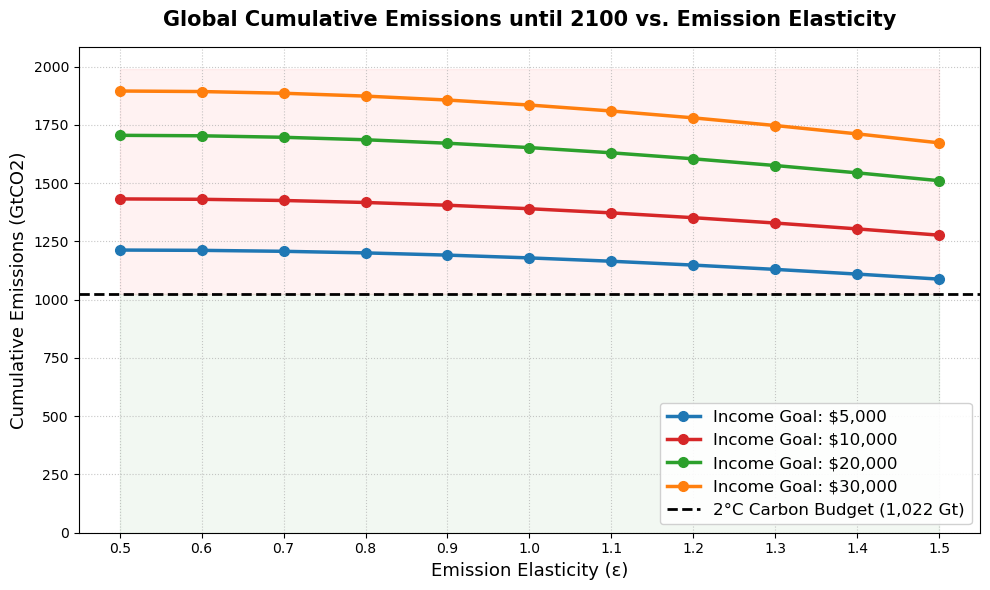

In [12]:
# 1. Safely change the current working directory to the main project root.
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    os.chdir('..')

# 2. Add the 'model_code' folder to sys.path so Python can find your classes
module_path = os.path.abspath('model_code')
if module_path not in sys.path:
    sys.path.append(module_path)

from scenario_class import Scenario

# Calculate the carbon budget in Gigatonnes for later reference
carbon_budget_gt = 1150 * 0.95 - 2 * 35

# Base scenario parameters
base_scenario_params = {
    "end_year": 2100, 
    "carbon_budget": carbon_budget_gt,     
    "gdp_assumption": "constant_ratio",         
    "pop_growth_assumption": "semi_log_model",  
    "tech_evolution_assumption": "plausible", 
    "tech_hysteresis_assumption": "off", 
    "steady_state_high_income_assumption": "off",
    "k": 0.05,
    "t0": 2060,
    "final_improvement_rate": -0.05,
    "population_hysteresis_assumption": "off",      
    "run_until_2100": "on", 
    "cdr_assumption": "on", 
    "cdr_level_2100": 5, 
    "elasticity_assumption": "constant"
}

income_goals = [5000, 10000, 20000, 30000]
elasticities = np.arange(0.5, 1.6, 0.1)
results = []

print("Running scenarios...")
for goal in income_goals:
    for elasticity in elasticities:
        params = base_scenario_params.copy()
        params["income_goal"] = goal
        params["elasticity_value"] = elasticity
        
        scenario = Scenario(params)
        scenario.compute_country_scenario_params()
        scenario.run()
        
        # Sum total emissions across all countries
        total_cumulative_emissions = sum(
            sum(country.emissions_trajectory.values()) 
            for country in scenario.countries.values()
        )
            
        # APPENDING WITH THE NEW KEYS
        results.append({
            "Income_Goal": goal,
            "Elasticity": elasticity,
            "Cumulative_Emissions_Gt": total_cumulative_emissions / 1e9  # Convert to Gigatonnes
        })
        print(f"Goal: ${goal:<6} | Elasticity: {elasticity:.1f} | Cumulative Emissions: {total_cumulative_emissions / 1e9:,.0f} Gt")


# --- Plotting the Results ---
df_results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']  # Blue, Red, Green, Orange

# Plot a line for each Income Goal scenario
for idx, goal in enumerate(income_goals):
    subset = df_results[df_results["Income_Goal"] == goal]
    # THIS WILL NOW WORK BECAUSE THE KEY WAS GENERATED IN THE LOOP ABOVE
    ax.plot(subset["Elasticity"], subset["Cumulative_Emissions_Gt"], 
            marker='o', linewidth=2.5, markersize=7, color=colors[idx],
            label=f'Income Goal: ${goal:,}')

# Add a horizontal line for the carbon budget
ax.axhline(y=carbon_budget_gt, color='black', linestyle='--', linewidth=2, 
           label=f'2°C Carbon Budget ({carbon_budget_gt:,.0f} Gt)')

# Fill the safe budget area for visual emphasis
ax.fill_between(elasticities, 0, carbon_budget_gt, color='green', alpha=0.05)
ax.fill_between(elasticities, carbon_budget_gt, df_results["Cumulative_Emissions_Gt"].max() * 1.05, color='red', alpha=0.05)

# Formatting the plot
ax.set_title("Global Cumulative Emissions until 2100 vs. Emission Elasticity", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Emission Elasticity (ε)", fontsize=13)
ax.set_ylabel("Cumulative Emissions (GtCO2)", fontsize=13)
ax.set_xticks(elasticities)
ax.set_ylim(bottom=0, top=df_results["Cumulative_Emissions_Gt"].max() * 1.1)
ax.set_xlim(left=0.45, right=1.55)
ax.legend(fontsize=12, loc='lower right', framealpha=0.9)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig("elasticity_emissions_comparison.png", dpi=300)
plt.show()